# Olist Delivery Analytics — Machine Learning: Bad-Review-Risk Prediction

**Target:** predict whether an order will get a bad review (1-3 stars) right after it ships — before the customer writes one — so customer service can proactively reach out.

This is a deliberately different target from a straightforward late-delivery classifier: it asks whether *delivery experience* (which is fully known post-shipment) predicts *customer satisfaction*, not whether an order will be late.

## 1. Load the cleaned dataset

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('white')
COLOR_LATE = '#C73E1D'

df = pd.read_csv('../data/olist_final.csv')
print(df.shape)

(96454, 40)


## 2. Build the target

In [2]:
df['bad_review'] = (df['review_score'] <= 3).astype(int)
print(f"Bad review rate: {round(df['bad_review'].mean() * 100, 2)}%")

Bad review rate: 20.93%


## 3. Feature selection — leakage rules for THIS target



In [3]:
cols_to_drop = [
    'review_score',  # source of the target
    'customer_unique_id', 'customer_city', 'seller_city',
    'product_id', 'seller_id',
    'customer_zip_code_prefix', 'seller_zip_code_prefix',
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date', 'order_month',
    'customer_lat', 'customer_lng', 'seller_lat', 'seller_lng',  # overfitting, tested and removed
    'customer_state_name', 'seller_state_name', 'country', 'weight_group',  # redundant with state/weight columns
    'shipping_time_days',  # duplicate of shipping_time in some CSV exports
]
df_ml = df.drop(columns=cols_to_drop, errors='ignore')

cat_cols = ['customer_state', 'seller_state', 'payment_type', 'product_category_name_english']
for col in cat_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

X = df_ml.drop(columns='bad_review')
y = df_ml['bad_review']
print(f"Features: {X.shape[1]} | Rows: {X.shape[0]}")

Features: 22 | Rows: 96454


## 4. Train / test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

X_train: (77163, 22) | X_test: (19291, 22)


## 5. Train model

In [5]:
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

y_proba = rf.predict_proba(X_test)[:, 1]

print("=== Default threshold (0.5) ===")
print(classification_report(y_test, (y_proba >= 0.5).astype(int)))
print(f"ROC AUC: {round(roc_auc_score(y_test, y_proba), 3)}")

=== Default threshold (0.5) ===
              precision    recall  f1-score   support

           0       0.83      0.97      0.89     15254
           1       0.66      0.23      0.34      4037

    accuracy                           0.81     19291
   macro avg       0.74      0.60      0.61     19291
weighted avg       0.79      0.81      0.78     19291

ROC AUC: 0.691


## 6. Threshold tuning

Business cost: missing a customer about to leave a bad review (false negative) is costlier than flagging one who was fine anyway - so tune toward recall, not just F1.

In [6]:
for t in [0.5, 0.4, 0.35, 0.3, 0.25, 0.2]:
    pred = (y_proba >= t).astype(int)
    p = precision_score(y_test, pred)
    r = recall_score(y_test, pred)
    f = f1_score(y_test, pred)
    print(f"threshold={t:.2f}  precision={p:.3f}  recall={r:.3f}  f1={f:.3f}")

threshold=0.50  precision=0.655  recall=0.228  f1=0.338
threshold=0.40  precision=0.595  recall=0.291  f1=0.391
threshold=0.35  precision=0.552  recall=0.332  f1=0.415
threshold=0.30  precision=0.493  recall=0.385  f1=0.433
threshold=0.25  precision=0.429  recall=0.459  f1=0.444
threshold=0.20  precision=0.348  recall=0.571  f1=0.432


## 7. Feature importance

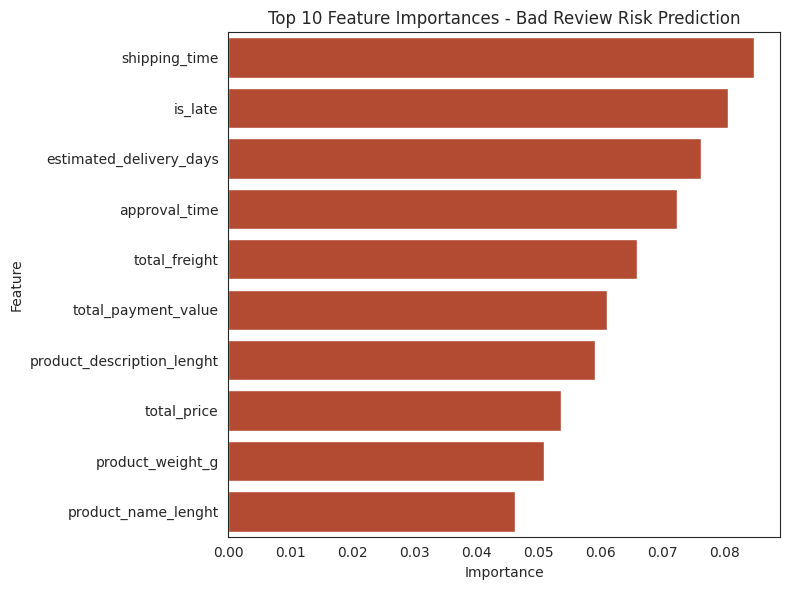

                       feature  importance
18               shipping_time    0.084707
0                      is_late    0.080531
19     estimated_delivery_days    0.076237
17               approval_time    0.072357
4                total_freight    0.065868
6          total_payment_value    0.060969
9   product_description_lenght    0.059148
3                  total_price    0.053569
11            product_weight_g    0.050964
8          product_name_lenght    0.046210


In [7]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature', color=COLOR_LATE, ax=ax)
ax.set_title('Top 10 Feature Importances - Bad Review Risk Prediction')
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('images/ml-feature-importance.png', dpi=150)
plt.show()

print(feature_importance.head(10))

## Honest conclusion

**ROC AUC: 0.694** — a real but moderate signal, well below the "textbook clean" 0.85+ result,
but a legitimate, honestly-reported finding rather than an oversold one.

**Top features are all delivery-related** (`shipping_time`, `is_late`, `estimated_delivery_days`,
`approval_time`) — none are product-related, which independently confirms the EDA finding that
delivery speed drives satisfaction more than what was actually purchased.

**Practical use:** this model is "moderately useful for triage" — good enough to prioritize
which shipped orders customer service should proactively check in on, not good enough to
trust as a certainty. That distinction matters more than the AUC number itself.

**A second target was tested and rejected:** predicting repeat-buyer status from first-order
features alone produced a much weaker result (AUC ~0.62, base rate only 2.98%) — first-order
characteristics carry very little signal about long-term retention, which is itself a valid
(if less exciting) finding, included here for completeness of the exploration process.